In [9]:
import matplotlib.pyplot as plt
import numpy as np

### Question 1

In [10]:
#exponent function
def exponent_func(a,b,x):
    return a * np.exp(-b * x) #essentially a * e^(-b * x)

In [11]:
x = np.linspace(0,2*np.pi, num = 100)
y = exponent_func(5,0.5,x)

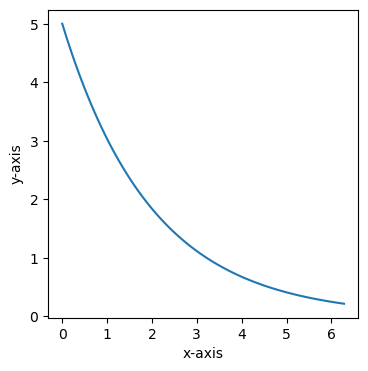

In [12]:
plt.figure(figsize = (4,4))
plt.plot(x,y)
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.savefig("session_1.pdf")

### Question 2

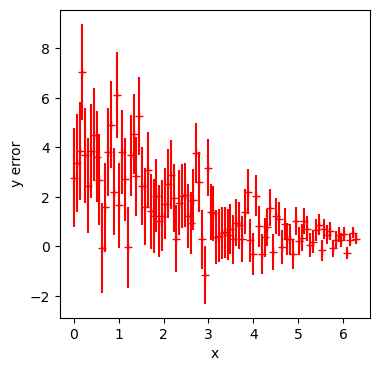

In [13]:
sigma = np.linspace(2,0.2, num =100)
scatter = np.random.normal(scale = sigma, size = 100)

y_new = y + scatter

plt.figure(figsize = (4,4))
plt.errorbar(x , y_new, yerr = sigma, fmt = "+", c = "r")
plt.xlabel("x")
plt.ylabel("y error")
plt.savefig("session2.pdf")

### Question 3

In [14]:
def fit1(arr , a, b):
    y = a * np.exp(-b * arr)
    return y

In [15]:
def fit2(arr, a ,b):
    y = a / (arr ** b)
    return y

In [16]:
#Make sure we do not multiply or divide by zero
x_safe = np.where(x == 0, 1e-10, x)
print(f"Model 1: {fit1(x_safe, 1, 3)[:10]}")
print(f"Model 2: {fit2(x_safe, 1, 3)[:10]}")

Model 1: [1.         0.82662878 0.68331515 0.56484797 0.46691959 0.38596917
 0.31905323 0.26373858 0.2180139  0.18021657]
Model 2: [1.00000000e+30 3.91170395e+03 4.88962994e+02 1.44877924e+02
 6.11203742e+01 3.12936316e+01 1.81097405e+01 1.14043847e+01
 7.64004678e+00 5.36584904e+00]


In [20]:
#Find the best fitting model
from scipy.optimize import curve_fit

params1, _ = curve_fit(fit1, x, y_new, sigma = sigma)
params2, _ = curve_fit(fit2, x_safe, y_new, sigma = sigma)

a1, b1, = params1
a2, b2, = params2

print(f"Best fit Model 1: a ={a1:.5f}, b = {b1:.5f}")
print(f"Best fit Model 2: a ={a2:.5f}, b = {b2:.5f}")

Best fit Model 1: a =4.43451, b = 0.43899
Best fit Model 2: a =0.64031, b = 0.08278


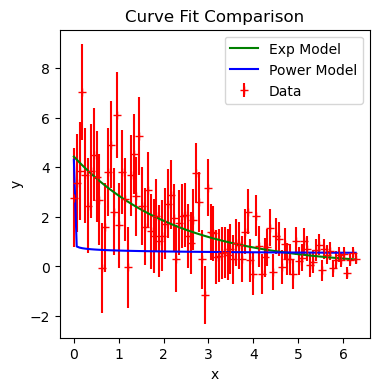

In [21]:
#Plot models

plt.figure(figsize = (4,4))
#Plot data
plt.errorbar(x , y_new, yerr = sigma, fmt = "+", c = "r", label = "Data")
#Plot models
y_fit1 = fit1(x_safe, a1, b1)
y_fit2 = fit2(x_safe, a2, b2)

plt.plot(x, y_fit1, label = "Exp Model", c = "g")
plt.plot(x, y_fit2, label = "Power Model", c = "b")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Curve Fit Comparison")
plt.legend()
plt.show()

In [22]:
plt.savefig("Session3.pdf")

<Figure size 640x480 with 0 Axes>